# Corporate Credit Rating Prediction

The objective of this notebook is to predict corporate credit ratings using a set of financial indicators describing a firm's liquidity, profitability, leverage, cash flow generation, and operating performance, as well as its industry sector.

This notebook is organized into four main parts:

1. **Intro**
2. **Data summary**
3. **Data preprocessing**
4. **Model training and evaluation**

# 1. Intro

## Dataset and sources

We use Alan Gewerc's [Corporate Credit Rating dataset on Kaggle](https://www.kaggle.com/datasets/agewerc/corporate-credit-rating). It contains **2,029 rating observations** for companies described by the author as traded on NYSE or Nasdaq, with 25 financial indicators, sector information and ratings from several agencies. An observation is a rating record, not necessarily a unique company.

The [CSV used in this exercise](kaggle/corporate_rating.csv) contains **2,027 observations dated 2010–2016 and two earlier observations**, one from 2005 and one from 2009. Its `Date` column runs from 16 August 2005 to 23 December 2016.

## Properties of the dataset

### How the dataset was constructed

The author's [source repository](https://github.com/Agewerc/ML-Finance) credits OpenDataSoft for rating histories and Financial Modeling Prep for financial ratios. The published [data-generation script](https://github.com/Agewerc/ML-Finance/blob/master/generateCreditRatingDataset.py) describes the matching process:

1. **Identify companies.** Clean company names and match them to a stock list to obtain ticker symbols.
2. **Prepare ratings.** Map Moody's labels toward an S&P-style letter scale, remove plus/minus modifiers and retain the selected rating classes. Pooling labels does not make agencies' methodologies identical.
3. **Join financials and ratings.** Match by ticker and year using the rule below.
4. **Remove incomplete data.** Drop columns with fewer than 5,900 nonmissing entries in the intermediate merged dataset, then drop remaining rows containing missing values. The threshold applies to the intermediate data, not the final 2,029 observations.
5. **Remove duplicates and export.** Deduplicate by cleaned company name and financial-ratio date before exporting the retained sample.

The final CSV contains six identifying or descriptive fields and 25 numerical financial indicators. Its lack of missing values results from filtering rather than imputation. Companies with incomplete reporting are excluded, which can favor firms with more complete financial data.


<table style="width:550px; max-width:100%; margin:0 auto; text-align:left;">
<thead><tr><th style="text-align:left;">Rating issued in year Y</th><th style="text-align:left;">Calendar year of financial-ratio date selected</th></tr></thead>
<tbody>
<tr><td style="text-align:left;">January–June</td><td style="text-align:left;">Previous year, Y−1</td></tr>
<tr><td style="text-align:left;">July–December</td><td style="text-align:left;">Same year, Y</td></tr>
</tbody>
</table>

<div style="width:550px; max-width:100%; margin:12px auto;">

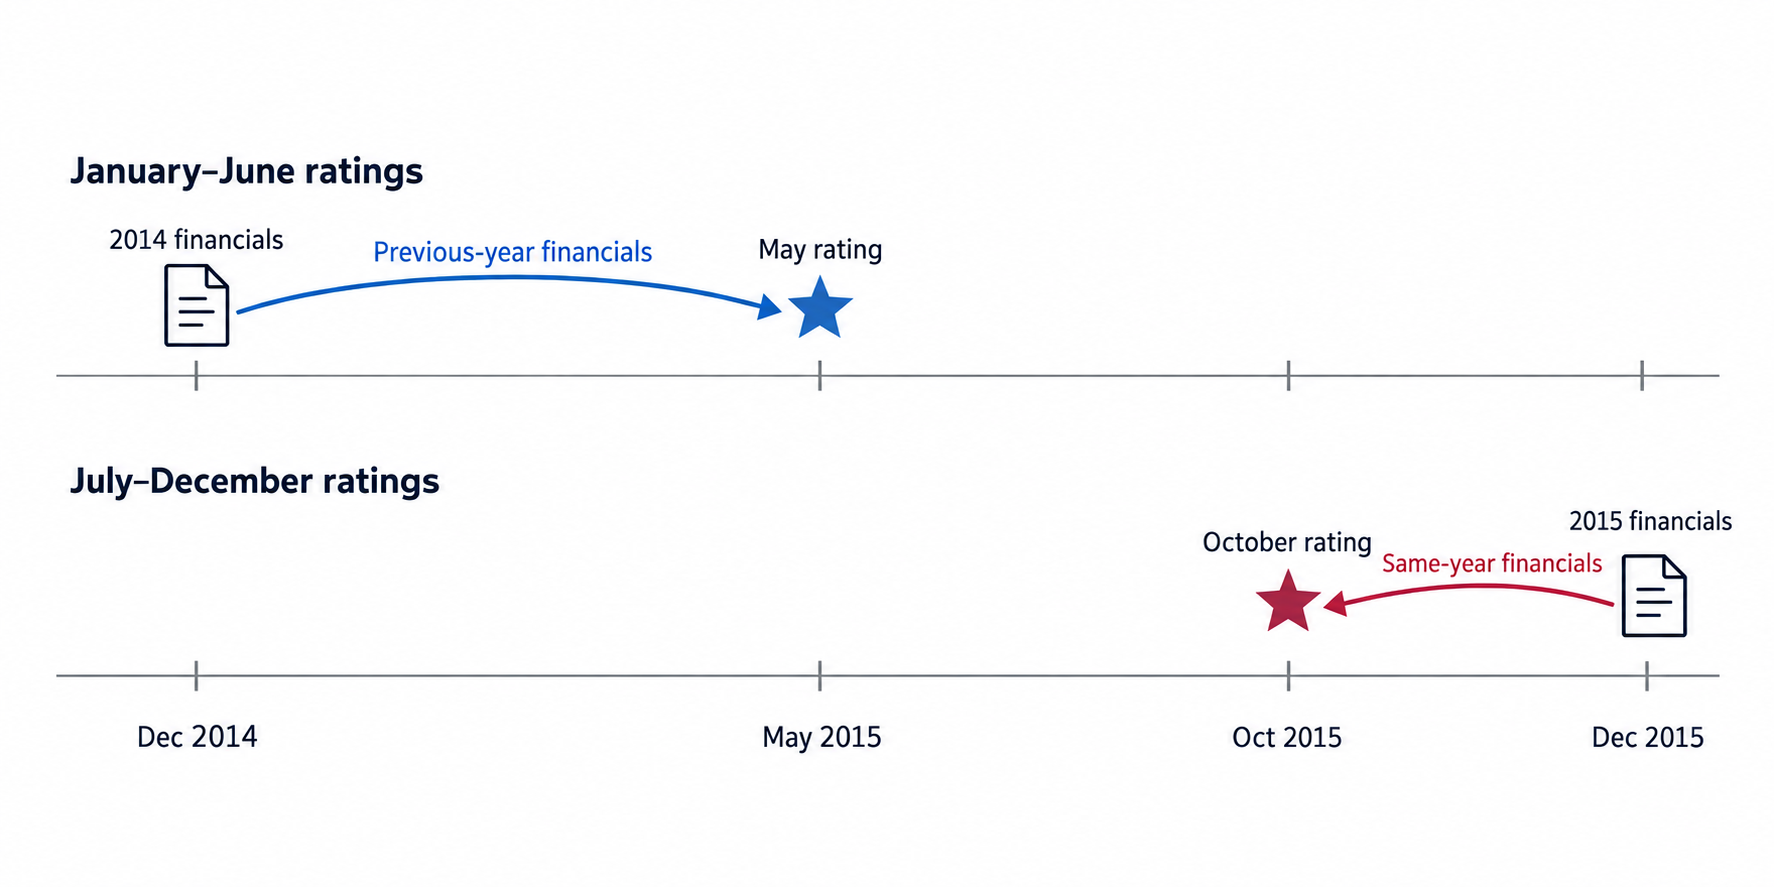

</div>

Example for a company with a December year-end. Arrows show the data assigned to each rating, not publication dates. The backward arrow illustrates how same-year financials can introduce information from after the rating date.
The script joins on the calendar year of the returned financial-ratio date, without checking publication dates or reconciling fiscal calendars. It documents the intended construction method; it has not been verified to reproduce the exact Kaggle CSV unchanged.

### Further reading

- [Author's original Kaggle modelling notebook](https://www.kaggle.com/code/agewerc/corporate-credit-rating-forecasting)

### Look-ahead bias

Look-ahead bias occurs when a model uses information that was not yet available at the prediction date. Two aspects of the published construction method can introduce this bias:

1. **Year-matching rule.** Ratings issued in July–December are matched to financials from the same year. For a December year-end company, an October 2015 rating can therefore receive full-year 2015 financials, including activity after the rating date.
2. **Publication lag.** Financials are not shifted to reflect the delay between the end of the reporting period and publication. Even prior-year accounts may be unavailable at an early-year rating date. For example, 2014 accounts may not yet have been published when a January 2015 rating was issued.

Both issues can overstate historical prediction performance. To avoid them, each rating should be matched to the latest financial statements published on or before its date, using the data version available at that time.

The CSV does not retain financial-period dates, publication dates or historical data versions, so we cannot determine which individual records are affected. This exercise therefore illustrates rating classification rather than a verified forecast using only information available at the time.


### Rating agencies in the dataset

The dataset contains ratings from several agencies, some better known than others. The table below briefly introduces each agency.

| Rating agency | Description |
| --- | --- |
| [S&P Global Ratings](https://www.spglobal.com/ratings/en/products/credit-ratings) | Publishes credit-risk opinions on issuers and their debt. It appears in the dataset under its older name, Standard & Poor's Ratings Services. |
| [Moody's](https://www.moodys.com/web/en/us/help-support/faq.html) | Assesses the credit risk of companies, governments and financial obligations. The dataset labels it Moody's Investors Service. |
| [Fitch Ratings](https://www.fitchratings.com/about-us) | Publishes ratings and research for capital markets. |
| [Egan-Jones](https://egan-jones.com/company/history) | An independent rating agency founded in 1995, with services covering corporate debt and private credit. |
| [DBRS, now Morningstar DBRS](https://www.morningstar.com/company/leadership/detlef-scholz) | A global rating agency headquartered in Toronto. Morningstar acquired DBRS in 2019. |


### What feature categories do we look for?

Credit analysis considers a company's business strength, financial performance and ability to repay debt. The table below summarises the main feature categories.

| Category | Economic dimension | Time horizon | Typical relevance to ratings |
| --- | --- | --- | --- |
| Size and market position | Resilience, diversification | Structural / Long-term | Scale and a strong competitive position can support credit quality; size alone is insufficient |
| Growth | Sustainability of operations | Medium-term | Profitable, funded growth can help; debt-funded expansion can weaken credit quality |
| Volatility | Predictability of earnings and cash flow | Across the business cycle | Greater volatility generally increases credit risk |
| Profitability | Earnings generation | Ongoing | Sustained profitability supports debt-servicing capacity |
| Efficiency | Asset use and working-capital management | Ongoing | Efficient operations can support cash generation; turnover ratios need industry context |
| Liquidity | Ability to meet near-term obligations | Short-term | Adequate liquid resources and funding access support credit quality |
| Leverage and solvency | Financial structure sustainability | Long-term | More debt relative to earnings, cash flow or capital generally increases credit risk |
| Banking/insurance factors | Capital adequacy, asset quality and funding | Ongoing | Adequate capital and liquidity buffers support credit quality |
| Contextual variables | Industry, country and operating environment | Structural / Cyclical | Context affects the interpretation of financial ratios |

Further reading: [S&P's overview of credit-rating analysis](https://www.spglobal.com/ratings/en/credit-ratings/about/understanding-credit-ratings) and [Egan-Jones' methodology](https://www.sec.gov/Archives/edgar/data/1651331/000165133118000010/EJR_Methodologies.pdf).


### Available features and missing categories

The table lists all 25 numerical indicators and the sector predictor. Descriptions are economic interpretations, guided by [FMP's formula documentation](https://site.financialmodelingprep.com/developer/docs/formula). The historical API responses and underlying statements are unavailable, so exact denominator conventions and historical calculations cannot be fully verified from this CSV.

| Category | Feature name | Description |
| --- | --- | --- |
| Size and market position | None | No absolute size measure such as revenue, total assets or market capitalisation; no market-share measure |
| Growth | None | No precomputed growth rates |
| Volatility | None | No precomputed earnings, cash-flow or market volatility; repeated companies do not form a complete regular time series |
| Profitability | `netProfitMargin` | Net income / Revenue |
| | `pretaxProfitMargin` | Pretax income / Revenue |
| | `grossProfitMargin` | Gross profit / Revenue |
| | `operatingProfitMargin` | Operating income / Revenue |
| | `ebitPerRevenue` | EBIT / Revenue |
| | `returnOnAssets` | Net income relative to total assets |
| | `returnOnEquity` | Net income relative to equity |
| | `returnOnCapitalEmployed` | Operating earnings relative to capital employed; the historical capital and averaging convention is unverified |
| Tax | `effectiveTaxRate` | Tax expense / Pretax income |
| Valuation | `enterpriseValueMultiple` | Enterprise value / EBITDA |
| Cash flow | `operatingCashFlowSalesRatio` | Operating cash flow / Revenue |
| | `operatingCashFlowPerShare` | Operating cash flow per share |
| | `freeCashFlowPerShare` | Free cash flow per share |
| | `freeCashFlowOperatingCashFlowRatio` | Free cash flow / Operating cash flow; interpretation is problematic when operating cash flow is zero or negative |
| Efficiency | `assetTurnover` | Revenue relative to total assets |
| | `fixedAssetTurnover` | Revenue relative to net property, plant and equipment |
| | `daysOfSalesOutstanding` | Receivables collection period, measured in days |
| | `payablesTurnover` | Payables turnover, measured in times per period; distinct from days payable. The historical numerator and averaging convention are unverified |
| Liquidity | `currentRatio` | Current assets / Current liabilities |
| | `quickRatio` | Cash and cash equivalents, short-term investments and receivables / Current liabilities |
| | `cashRatio` | Cash and cash equivalents / Current liabilities |
| | `cashPerShare` | Cash per share; not a direct measure of coverage of liabilities |
| Solvency / Leverage | `debtRatio` | FMP documents total liabilities / Total assets; liabilities include more than interest-bearing debt |
| | `debtEquityRatio` | FMP's formula page documents total liabilities / Equity; the historical debt definition is not independently verified |
| | `companyEquityMultiplier` | Total assets / Equity |
| Banking / Insurance | None | No dedicated capital-adequacy, loan-quality or insurance-underwriting ratios |
| Context | `Sector` | One sector label per record; no country or region field |

Other missing credit inputs include interest coverage, debt-service coverage, debt maturities, funding access and governance. Per-share measures do not establish company size. The CSV also contains rating, company name, ticker, agency and date fields; these are labels or metadata rather than the financial predictors listed above.


### Corporates and financials in the dataset

The table below groups the CSV records by their Kaggle sector labels. Counts refer to rating records, not unique companies. This is a sector-based approximation of the corporate/financial split; a classification for credit analysis requires company-level review.

| Broader category | Kaggle sectors | Records |
| --- | --- | ---: |
| Corporate sectors, provisional | Energy, Basic Industries, Consumer Services, Technology, Capital Goods, Public Utilities, Health Care, Consumer Non-Durables, Consumer Durables, Transportation | 1,922 |
| Finance sector | Finance | 50 |
| Needs company-level review | Miscellaneous | 57 |
| Total | | 2,029 |

For example, `Finance` includes Equifax and S&P Global alongside insurers, while `Miscellaneous` includes Visa, Mastercard and PayPal. The 50 Finance records therefore do not represent a verified count of bank and insurer observations.


## Import libraries

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Set a random state
RANDOM_STATE = 1234

# 2. Data summary

Before building effective predictive models, it is essential to gain a thorough understanding of the data. We need to know what each observation represents, identify the target variable we want to predict, assess the amount of data available, and examine the explanatory variables and their distributions. It is also important to investigate potential correlations between variables, evaluate their relevance, and detect issues such as missing values, outliers, or other data quality concerns. These are the aspects that will be explored in this first section.

## Load and identify the observations


In [ ]:
# Importing data
path = 'kaggle/corporate_rating.csv'
df_rating = pd.read_csv(path)

In [ ]:
# Check dataset shape
n_rows, n_cols = df_rating.shape
print(f"This dataset contains {n_rows} observations and {n_cols} columns.")

In [ ]:
# Let's look at the dataset
df_rating.head()

In [ ]:
# Summarise all variables in a compact, scrollable table.
from IPython.display import HTML

summary_data = pd.read_csv("kaggle/corporate_rating.csv")
variable_summary = pd.DataFrame({
    "variable": summary_data.columns,
    "type": summary_data.dtypes.astype(str).values,
    "non_null": summary_data.notna().sum().values,
    "missing": summary_data.isna().sum().values,
    "unique_values": summary_data.nunique().values,
})
summary_table = (
    variable_summary.style.hide(axis="index")
    .set_table_styles([
        {"selector": "th, td", "props": [("font-size", "12px"), ("padding", "3px 8px")]},
        {"selector": "td.col0", "props": [("text-align", "left")]},
    ])
    .to_html()
)
display(HTML(
    '<div style="max-height:320px; overflow:auto; width:fit-content; max-width:100%;" '
    'tabindex="0" role="region" aria-label="Variable summary; scroll to view all 31 variables">'
    + summary_table + '</div>'
))


We can observe that the dataset contains no missing values. It consists of 31 variables in total, including 6 categorical (string) variables and 25 numerical variables.

In [ ]:
# Let's look at the number of companies rated in the dataset
n_companies = df_rating["Name"].nunique()
print(f'The dataset contains information on {n_companies} different companies.')

## Data distribution analysis


Analyzing the data distribution is a crucial step in understanding the dataset. It helps assess class balance, identify potential issues, and determine whether transformations, scaling, or normalization are needed before training predictive models.

We will not examine all financial ratios here, but many of them exhibit strong skewness: most observations are concentrated around relatively small values, while a small number of observations are extremely large. In such cases, the mean is pulled away from the median, and the maximum value can be several times larger than both. Skewness summarizes this asymmetry: a value close to zero indicates a roughly symmetric distribution, whereas a large absolute value indicates a pronounced tail.

The cell below identifies the most skewed numerical features. The two plots then use the most skewed feature as an illustrative example: the boxplot displays the full sample, while the histogram focuses on the central 98% of observations to make the main body of the distribution more visible. This highlights the need to transform the numerical features, as will be done in the data preprocessing stage.

In [ ]:
# Summarise the distributions of all numerical features
numerical_columns = df_rating.select_dtypes(include="number").columns
numerical_distribution = pd.DataFrame({
    "mean": df_rating[numerical_columns].mean(),
    "median": df_rating[numerical_columns].median(),
    "99th percentile": df_rating[numerical_columns].quantile(0.99),
    "maximum": df_rating[numerical_columns].max(),
    "skewness": df_rating[numerical_columns].skew(),
})
numerical_distribution["absolute skewness"] = numerical_distribution["skewness"].abs()
numerical_distribution = numerical_distribution.sort_values("absolute skewness", ascending=False)

display(
    numerical_distribution.head(8).drop(columns="absolute skewness")
    .style.format("{:.2f}")
    .set_properties(subset=["skewness"], **{
        "background-color": "#F2CF5B", "color": "#202020", "font-weight": "bold"
    })
    .set_table_styles([{
        "selector": "th.col_heading.col4",
        "props": [("background-color", "#F2CF5B"), ("color", "#202020"), ("font-weight", "bold")]
    }])
)

# Illustrate the most skewed variable
example_feature = numerical_distribution.index[0]
example_data = df_rating[example_feature].dropna()
lower_bound = example_data.quantile(0.01)
upper_bound = example_data.quantile(0.99)
central_data = example_data.between(lower_bound, upper_bound)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=example_data, color="#4C78A8", ax=axes[0])
axes[0].set_title(f"{example_feature}: full sample")
axes[0].set_xlabel(example_feature)
sns.histplot(example_data[central_data], bins=30, kde=True, color="#4C78A8", ax=axes[1])
axes[1].set_title(f"{example_feature}: central 98%")
axes[1].set_xlabel(example_feature)
fig.suptitle(
    f"Mean = {example_data.mean():.2f} | Median = {example_data.median():.2f} | "
    f"Maximum = {example_data.max():.2f} | Skewness = {example_data.skew():.2f}",
    fontsize=13,
)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# Plot the rating distribution
rating_order = ["AAA", "AA", "A", "BBB", "BB", "B", "CCC", "CC", "C", "D"]
counts = pd.read_csv("kaggle/corporate_rating.csv", usecols=["Rating"])["Rating"].value_counts().reindex(rating_order, fill_value=0)
fig, ax = plt.subplots(figsize=(7, 2.8))
bars = ax.bar(counts.index, counts.values, color="#4C78A8", edgecolor="black", alpha=0.85)
ax.bar_label(bars, fmt="%d", padding=3, fontsize=9, fontweight="bold")
ax.set_title("Rating distribution", fontsize=12, pad=10)
ax.set_xlabel("Rating")
ax.set_ylabel("Number of observations")
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

There are several points to note here. First, we do not take the time dimension into account, even though the distribution may change over time. Moreover, this distribution could be biased if the number of observations varies significantly across different periods.

Second, we observe that some ratings have very few observations, particularly AAA, CCC, CC, C, and D. This class imbalance can lead a predictive model to focus primarily on the majority classes, resulting in misleadingly high accuracy while exhibiting poor performance in identifying observations from the minority classes.

To mitigate the second issue and simplify the analysis, we follow the approach used in [Alan Gewerc's original Kaggle notebook](https://www.kaggle.com/code/agewerc/corporate-credit-rating-forecasting) and merge certain ratings into broader, more robust, and economically meaningful categories. The ratings will therefore be grouped into larger risk categories, as follows. In addition, the AAA and D categories will be excluded due to their very limited number of observations.

Broader categories reduce class sparsity but sacrifice notch-level detail.

In [ ]:
# Replace ratings with broader risk levels
rating_dict = {'AAA':'Lowest Risk', 
               'AA':'Low Risk',
               'A':'Low Risk',
               'BBB':'Medium Risk', 
               'BB':'High Risk',
               'B':'High Risk',
               'CCC':'Highest Risk', 
               'CC':'Highest Risk',
               'C':'Highest Risk',
               'D':'In Default'}
df_rating["Rating"] = df_rating["Rating"].replace(rating_dict)

The "Lowest Risk" and "In Default" categories remain underrepresented, with only a limited number of observations. Consequently, observations belonging to these categories will be excluded from the dataset.

In [ ]:
# Dropping observations classified as 'Lowest Risk' or 'In Default' 
df_rating = df_rating[df_rating['Rating']!='Lowest Risk']
df_rating = df_rating[df_rating['Rating']!='In Default']
df_rating.reset_index(inplace = True, drop=True)

We can also look at the distribution of rating classes and observe that it can vary across economic sectors.

In [ ]:
# Use a separate copy of the source data so this plot also works after preprocessing.
sector_ratings = pd.read_csv("kaggle/corporate_rating.csv", usecols=["Sector", "Rating"])
sector_rating_map = {
    "AAA": "Lowest Risk", "AA": "Low Risk", "A": "Low Risk",
    "BBB": "Medium Risk", "BB": "High Risk", "B": "High Risk",
    "CCC": "Highest Risk", "CC": "Highest Risk", "C": "Highest Risk", "D": "In Default",
}
sector_ratings["Rating"] = sector_ratings["Rating"].map(sector_rating_map)
if sector_ratings["Rating"].isna().any():
    raise ValueError("Source data contains missing or unrecognised rating labels")
sector_ratings = sector_ratings[sector_ratings["Rating"].isin(
    ["Low Risk", "Medium Risk", "High Risk", "Highest Risk"]
)]

# Compare rating proportions across sectors on a common percentage scale.
rating_band_order = ["Low Risk", "Medium Risk", "High Risk", "Highest Risk"]
rating_colors = ["#59A14F", "#F2CF5B", "#F28E2B", "#B07AA1"]
sector_counts = pd.crosstab(sector_ratings["Sector"], sector_ratings["Rating"]).reindex(
    columns=rating_band_order, fill_value=0
).sort_index()
sector_totals = sector_counts.sum(axis=1)
sector_shares = sector_counts.div(sector_totals, axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5.5))
left = np.zeros(len(sector_shares))
for band, color in zip(rating_band_order, rating_colors):
    values = sector_shares[band].to_numpy()
    ax.barh(sector_shares.index, values, left=left, label=band,
            color=color, height=0.7, edgecolor="white", linewidth=0.5)
    for row, (start, value) in enumerate(zip(left, values)):
        if value >= 7:
            ax.text(start + value / 2, row, f"{value:.0f}%", ha="center", va="center",
                    fontsize=9, color="#202020" if band == "Medium Risk" else "white")
    left += values

ax.set_yticks(range(len(sector_shares)))
ax.set_yticklabels([f"{sector} (n={sector_totals[sector]:,})" for sector in sector_shares.index])
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100], ["0%", "25%", "50%", "75%", "100%"])
ax.set_xlabel("Share of rating observations")
ax.set_ylabel("")
ax.set_title("Rating distribution by sector", loc="left", pad=12)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=4, frameon=False)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()


The chart shows that rating distributions vary substantially across sectors. Public Utilities and Consumer Non-Durables tend to have stable, defensive cash flows, which may explain their larger share of low-risk ratings. Conversely, Consumer Services, Basic Industries, and Consumer Durables are generally more exposed to economic cycles, volatile demand, and financial leverage, resulting in more high-risk observations. Technology firms may also face rapid innovation and uncertain earnings. However, some results, particularly for Finance and Transportation, may reflect the small sample, firm composition, or differences in rating dates, so they should be interpreted cautiously.

# 3. Data preprocessing


Now that we have a clearer understanding of the data, we need to perform some preprocessing before feeding it into the models. Specifically, categorical variables need to be encoded, and numerical features need to be normalized. We also need to split the dataset into a training set for fitting the models and a test set for evaluating their predictive performance, while ensuring that no data leakage occurs.

## Categorical variable encoding

Ratings can therefore be encoded using integer values that preserve their ordering, while the "Sector" variable is transformed into a set of dummy variables, with one binary column per sector taking the value 1 for the corresponding sector and 0 otherwise. Although this encoding step can be incorporated into a preprocessing pipeline using scikit-learn's `OneHotEncoder`, we implement it explicitly here.

Note that we do not consider dates here, as incorporating temporal information would add significant complexity. However, this could be a valuable improvement, potentially enabling the prediction or anticipation of future rating changes.

In [ ]:
# Target variable encoding methodology
risk_order = ["Low Risk", "Medium Risk", "High Risk", "Highest Risk"]
rating_to_int = {rating: code for code, rating in enumerate(risk_order)}

# Map the 'Rating' column using the rating_to_int dictionary
df_rating['Rating'] = df_rating['Rating'].map(rating_to_int)

In [ ]:
# Encoding the 'Sector' variable
df_sector = pd.get_dummies(
    df_rating["Sector"],
    prefix="Sector",
    dtype=int,
)

In [ ]:
# Replace the 'Sector' column with dummy variables
df_rating = pd.concat([df_rating.drop(columns=["Sector"]), df_sector], axis=1)

## Train/test split

Let's now perform a train-test split, with 80% of the observations assigned to the training set and 20% reserved for evaluating the models.

In [ ]:
# TO DO: Write a function that splits the dataset into a training set (80%) and a test set (20%)
def train_test_splitting(df):
    """Partition the data into training (80%) and held-out test (20%) datasets.

    Both returned DataFrames retain the input columns and original index.
    Together, they contain every input row exactly once.

    Returns
    -------
    train_df : pandas.DataFrame
        Observations used for model training.
    test_df : pandas.DataFrame
        Observations reserved for evaluation.
    """

    return train_df, test_df

In [ ]:
train_df, test_df = train_test_splitting(df_rating)

# Separating the target from the explanatory variables in both train and test sets
X_train = train_df.drop(columns=["Rating"]) 
y_train = train_df["Rating"]  
X_test = test_df.drop(columns=["Rating"]) 
y_test = test_df["Rating"]  

In [ ]:
# Checking the rating distribution in both the training and test sets
class_balance = pd.concat(
    {
        "train": train_df["Rating"].value_counts(normalize=True),
        "test": test_df["Rating"].value_counts(normalize=True),
    },
    axis=1,
).fillna(0)
display(class_balance.style.format("{:.1%}"))

We can now split the data into the target variable and the explanatory variables for both the training and test sets.


## Numerical feature normalization


Due to the significant skewness and presence of extreme values in the financial explanatory variables (as shown in the previous section), we first apply Min-Max scaling, which linearly rescales each feature so that its values lie within a specified range, typically between 0 and 1, based on the minimum and maximum values observed in the training data. We then apply a logarithmic transformation to the numerical variables. A small constant (0.01) is added beforehand because the logarithm of zero is undefined.

Note that normalization needs to be performed after the train-test split to prevent data leakage. The scaling parameters are estimated exclusively on the training set and subsequently applied to both the training and test sets, ensuring that the test data remain completely unseen during model training.

In [ ]:
# Numerical data normalization
numeric_features = [
    col for col in X_train.select_dtypes(include="number").columns
    if not col.startswith("Sector_")
]
train_min = X_train[numeric_features].min()
train_range = (X_train[numeric_features].max() - train_min).replace(0, 1)
sector_features = X_train.filter(regex=r"^Sector_").columns

def preprocess(X):
    scaled = ((X[numeric_features] - train_min) / train_range).clip(lower=0)
    return pd.concat([np.log(scaled + 0.01), X[sector_features]], axis=1)

X_train, X_test = preprocess(X_train), preprocess(X_test)

At this stage, all preprocessing steps have been completed, and the data are ready to be used by the predictive models.

# 4. Model training and evaluation


Before fitting the models, we define a common evaluation function. Each metric provides a different view of predictive performance:

- Accuracy is the overall proportion of correct predictions, but it can be dominated by frequent classes.
- Balanced accuracy is the average recall across classes and therefore gives equal importance to rare and frequent ratings.
- Macro F1 averages the F1-score of each class and rewards a balance between precision and recall.
- Mean absolute class error uses the ordered rating codes and measures how many risk levels separate the prediction from the true rating; lower is better.
- Quadratic weighted kappa measures ordinal agreement beyond chance and penalises distant rating errors more strongly; higher is better.

All scores are computed on the same untouched company-disjoint test set.

For definitions and examples, see the [Scikit-learn classification metrics documentation](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics).


In [ ]:
# Defining evaluation metrics for every classifier
def score_predictions(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "mean_absolute_class_error": np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))),
        "quadratic_weighted_kappa": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
    }

# Storing models results
fitted_models = {}
predictions = {}
model_scores = {}


## Model 1 — Gaussian Naive Bayes

Gaussian Naive Bayes models each feature with a Gaussian distribution within each rating class. You can adjust the following parameters to try to obtain the best accuracy.

Parameters to explore:
- `var_smoothing` adds numerical stability to the estimated variances. Larger values produce smoother, less extreme predictions.
- `priors` sets the class probabilities before observing the features. `None` learns them from the training data, while explicit values can give defined weights to each rating class.

In [ ]:
# TO DO: adjust these parameters and rerun the cell
gnb_params = {
    "priors": None,          # Example: None or [0.25, 0.25, 0.25, 0.25]
    "var_smoothing": 1       # Example: 1e-3, 1e-2, 1e-1 or 1.0
}

# Train the model and predict the test set
gnb_model = GaussianNB(**gnb_params)
gnb_model.fit(X_train, y_train)
gnb_predictions = gnb_model.predict(X_test)

# Compute and display the evaluation scores
gnb_scores = score_predictions(y_test, gnb_predictions)
display(pd.Series(gnb_scores, name="Gaussian Naive Bayes"))

# Storing results
fitted_models["Naive Bayes"] = gnb_model
predictions["Naive Bayes"] = gnb_predictions
model_scores["Naive Bayes"] = gnb_scores


## Model 2 — K-nearest neighbours

KNN predicts a rating from the classes of the closest training observations. Its behaviour depends directly on how neighbourhood and distance are defined.

Parameters to explore:
- `n_neighbors` controls the neighbourhood size. Small values make the model more local and flexible; larger values produce smoother predictions.
- `weights` gives either equal influence to all neighbours (`uniform`) or more influence to closer observations (`distance`).
- `p` selects the distance when `metric="minkowski"`: `1` gives Manhattan distance and `2` gives Euclidean distance.

In [ ]:
# TO DO: adjust these parameters and rerun the cell
knn_params = {
    "n_neighbors": 15,      # Example: 5, 15, 30, 50, 100
    "weights": "distance",  # "uniform" or "distance"
    "metric": "minkowski",
    "p": 2,                 # 1 = Manhattan, 2 = Euclidean
}

# Train the model and predict the test set
knn_model = KNeighborsClassifier(**knn_params)
knn_model.fit(X_train, y_train)
knn_predictions = knn_model.predict(X_test)

# Compute and display the evaluation scores
knn_scores = score_predictions(y_test, knn_predictions)
display(pd.Series(knn_scores, name="K-nearest neighbours"))

# Storing results
fitted_models["KNN"] = knn_model
predictions["KNN"] = knn_predictions
model_scores["KNN"] = knn_scores


## Model 3 — Multinomial logistic regression

Multinomial logistic regression estimates one set of class probabilities from a linear combination of the features.

Parameters to explore:
- `C` controls regularisation. Smaller values impose stronger regularisation and simpler coefficients; larger values allow the model to fit the training data more closely.
- `class_weight` can be set to `None` or `"balanced"`. The balanced option gives more importance to minority rating classes.
- `max_iter` is the maximum number of optimisation iterations. It should be increased only if the model does not converge.

In [ ]:
# TO DO: adjust these parameters and rerun the cell
logistic_params = {
    "C": 1.0,
    "class_weight": "balanced",
    "max_iter": 10000,
    "random_state": RANDOM_STATE,
}

# Train the model and predict the test set
logistic_model = LogisticRegression(**logistic_params)
logistic_model.fit(X_train, y_train)
logistic_predictions = logistic_model.predict(X_test)

# Compute and display the evaluation scores
logistic_scores = score_predictions(y_test, logistic_predictions)
display(pd.Series(logistic_scores, name="Logistic regression"))

# Storing results
fitted_models["Logistic regression"] = logistic_model
predictions["Logistic regression"] = logistic_predictions
model_scores["Logistic regression"] = logistic_scores


## Model 4 — XGBoost

XGBoost combines many decision trees built sequentially, with each new tree correcting part of the previous errors.

Parameters to explore:
- `n_estimators` is the number of trees. More trees can improve learning but increase computation and overfitting risk.
- `max_depth` controls the complexity of each tree. Deeper trees capture more interactions but overfit more easily.
- `learning_rate` controls the contribution of each new tree. Smaller values generally require more trees.
- `subsample` is the fraction of training observations used for each tree. Values below 1 can reduce overfitting.
- `colsample_bytree` is the fraction of features considered for each tree and can also reduce overfitting.

In [ ]:
# TO DO: adjust these parameters and rerun the cell
xgboost_params = {
    "n_estimators": 300,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "objective": "multi:softprob",
    "num_class": len(risk_order),
    "eval_metric": "mlogloss",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

# Train the model and predict the test set
xgboost_model = XGBClassifier(**xgboost_params)
xgboost_model.fit(X_train, y_train)
xgboost_predictions = xgboost_model.predict(X_test)

# Compute and display the evaluation scores
xgboost_scores = score_predictions(y_test, xgboost_predictions)
display(pd.Series(xgboost_scores, name="XGBoost"))

# Storing results
fitted_models["XGBoost"] = xgboost_model
predictions["XGBoost"] = xgboost_predictions
model_scores["XGBoost"] = xgboost_scores


Let's now compare the scores of the four models!

In [ ]:
# Compare all models on the same test observations
model_results = (
    pd.DataFrame.from_dict(model_scores, orient="index")
    .sort_values("accuracy", ascending=False)
)
display(model_results.style.format("{:.3f}"))


Let's have a look at the confusion matrix for the best model, that we normalize by row: each row represents a true rating class and shows how its observations are distributed across the predicted classes.

In [ ]:
# Identify the best model and compute its confusion matrix
best_model_name = model_results.index[0]
best_pred = predictions[best_model_name]
ordered_codes = list(range(len(risk_order)))
cm = confusion_matrix(y_test, best_pred, labels=ordered_codes, normalize="true")

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt=".1%", cmap=sns.blend_palette(["#ffffff", "#4C78A8"], as_cmap=True), vmin=0, vmax=1, xticklabels=risk_order, yticklabels=risk_order, ax=ax)
ax.set(title=f"{best_model_name}: row-normalised confusion matrix", xlabel="Predicted", ylabel="Actual")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(classification_report(y_test, best_pred, labels=ordered_codes, target_names=risk_order, zero_division=0))


XGBoost achieves the best overall performance, suggesting that non-linear relationships and interactions between financial ratios are important. KNN performs reasonably well, while
logistic regression and Naive Bayes are more limited by their stronger assumptions. However, overall accuracy should be interpreted cautiously because it is largely driven by the most frequent risk classes.

Regarding the confusion matrix, XGBoost’s performance varies substantially across classes. In particular, the Highest Risk category has very low recall because it contains only 11 test observations, giving the model too little information to learn its characteristics reliably. These companies are often predicted as less risky, especially as High Risk. In practice, such underestimation is particularly concerning because it may provide false reassurance precisely where the financial consequences are greatest.

## Feature importance

Permutation importance measures how strongly the selected model relies on each feature. We first compute its baseline macro F1, then randomly shuffle one feature in the unseen-company test set and measure the decrease in the score. A larger decrease indicates greater importance. The process is repeated 20 times, and all sector dummy variables are shuffled together as one feature. The method works with any fitted model, but the reported importances belong only to the model selected above (XGBoost).


In [ ]:
# Select the best fitted model and calculate its baseline score.
best_model_name = model_results.index[0]
best_model = fitted_models[best_model_name]
baseline_macro_f1 = f1_score(
    y_test, best_model.predict(X_test), average="macro", zero_division=0
)

# Treat each numerical variable separately and Sector as one grouped feature.
feature_groups = {feature: [feature] for feature in numeric_features}
feature_groups["Sector"] = sector_features
rng = np.random.default_rng(RANDOM_STATE)

def permutation_score_drop(columns, n_repeats=20):
    score_drops = []
    for _ in range(n_repeats):
        X_permuted = X_test.copy()
        X_permuted[columns] = X_test[columns].to_numpy()[rng.permutation(len(X_test))]
        score = f1_score(
            y_test, best_model.predict(X_permuted), average="macro", zero_division=0
        )
        score_drops.append(baseline_macro_f1 - score)
    return np.mean(score_drops), np.std(score_drops, ddof=1)

# Rank features by their average reduction in macro F1.
importance_rows = []
for feature, columns in feature_groups.items():
    importance_mean, importance_std = permutation_score_drop(columns)
    importance_rows.append({
        "feature": feature,
        "importance_mean": importance_mean,
        "importance_std": importance_std,
    })

feature_importance = (pd.DataFrame(importance_rows)
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True))
plot_data = feature_importance.head(15).sort_values("importance_mean")

# Display the 15 most important features.
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_data["feature"], plot_data["importance_mean"],
        xerr=plot_data["importance_std"], color="#4C78A8",
        edgecolor="white", alpha=0.9, capsize=3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title=f"{best_model_name}: permutation importance on unseen companies",
       xlabel="Decrease in macro F1 after permutation", ylabel="")
ax.grid(axis="x", linestyle="--", alpha=0.35)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

display(feature_importance.head(10).style.format({
    "importance_mean": "{:.4f}", "importance_std": "{:.4f}"
}))


The three most influential features are `returnOnAssets`, `operatingCashFlowPerShare` and `Sector`. Return on assets measures how efficiently a firm generates earnings from its asset base, while operating cash flow per share reflects the recurring cash available to service interest and debt. Sector captures structural differences in cyclicality, capital intensity, regulation and typical leverage. Economically, the model therefore relies mainly on profitability, debt-servicing capacity and the firm's operating environment to distinguish credit-risk levels.

These results show which variables improve the model's predictions, but not whether an increase in a variable raises or lowers credit risk. They should therefore be interpreted as predictive associations rather than causal effects.
